# Cell 1: import thư viện và đọc dữ liệu

In [1]:
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split
import sys
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('../')
from src.models.supervised import SentimentClassifier

df = pd.read_csv('../data/processed/cleaned_reviews.csv')
tfidf_matrix = sparse.load_npz('../data/processed/tfidf_matrix.npz')

display(df.head(2))

/var/folders/s3/h6hv6qkd01d4qr6_nb2f3m3m0000gn/T/ipykernel_10072/3804972490.py:11: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/cleaned_reviews.csv')


,address,categories,city,country,latitude,longitude,name,postalCode,province,reviews.date,reviews.dateAdded,reviews.doRecommend,reviews.id,reviews.rating,reviews.text,reviews.title,reviews.userCity,reviews.username,reviews.userProvince,cleaned_text
0,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2013-09-22T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,4.0,Pleasant 10 min walk along the sea front to th...,Good location away from the crouds,NaN,Russ (kent),NaN,pleasant min walk along sea front water bus re...
1,Riviera San Nicol 11/a,Hotels,Mableton,US,45.421611,12.376187,Hotel Russo Palace,30126,GA,2015-04-03T00:00:00Z,2016-10-24T00:00:25Z,NaN,NaN,5.0,Really lovely hotel. Stayed on the very top fl...,Great hotel with Jacuzzi bath!,NaN,A Traveler,NaN,really lovely hotel stayed top floor surprised...


# Cell 2: Tạo nhãn và chia tập dữ liệu

In [2]:
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['reviews.rating'].apply(get_sentiment)

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    tfidf_matrix, df['sentiment'], df.index, test_size=0.2, random_state=42, stratify=df['sentiment']
)

print(X_train.shape)
print(X_test.shape)

(26856, 3000)
(6714, 3000)


# Cell 3: Huấn luyện và đánh giá F1-macro

In [3]:
classifier = SentimentClassifier(random_state=42)
classifier.train_all(X_train, y_train)
results = classifier.evaluate_all(X_test, y_test)

f1_scores = {name: res['macro_f1'] for name, res in results.items()}

for name, score in f1_scores.items():
    print(f"{name} - Macro F1: {score:.4f}")

best_model_name = max(f1_scores, key=f1_scores.get)
print(f"Best Model: {best_model_name}")

Naive Bayes - Macro F1: 0.5659
Logistic Regression - Macro F1: 0.6010
Linear SVC - Macro F1: 0.5965
Best Model: Logistic Regression


# Cell 4: Trực quan hóa bằng Confusion Matrix

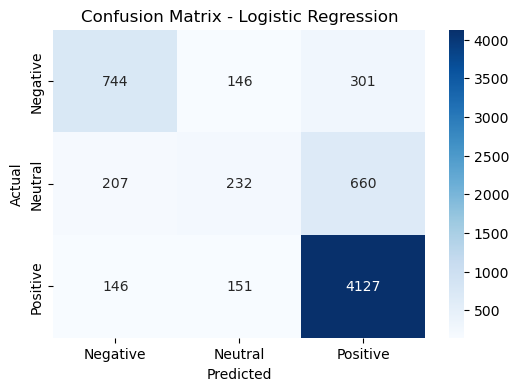

In [4]:
best_matrix = results[best_model_name]['matrix']
labels = sorted(df['sentiment'].unique())

plt.figure(figsize=(6, 4))
sns.heatmap(best_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Cell 5: Trích xuất lỗi Review đa chủ đề

In [5]:
df_test = df.loc[indices_test].copy()
df_test['predicted'] = results[best_model_name]['predictions']

errors = df_test[df_test['sentiment'] != df_test['predicted']]

multi_topic_errors = errors[errors['reviews.text'].str.len() > 200]
display(multi_topic_errors[['reviews.rating', 'sentiment', 'predicted', 'reviews.text']].head())

,reviews.rating,sentiment,predicted,reviews.text
19070,3.0,Neutral,Positive,We stayed at this Super 8 on the way to our fi...
15793,3.0,Neutral,Positive,"Nice and clean. Walls are paper thin so, as I,..."
8731,3.0,Neutral,Negative,Stay was fine only problem was they charged my...
8903,3.0,Neutral,Positive,Simple get-away stay-cation. We walked around ...
4028,2.0,Negative,Neutral,"This hotel is quite run down, and in need of r..."
